In [2]:
# 导入 所需 库

import os
#换用中国镜像站
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
#关闭SSL
os.environ["CURL_CA_BUNDLE"] = ""
os.environ["REQUESTS_CA_BUNDLE"] = ""
os.environ["NO_PROXY"] = "hf-mirror.com,cdn-lfs.hf-mirror.com"
for key in ["HTTP_PROXY", "HTTPS_PROXY", "http_proxy", "https_proxy"]:
    os.environ.pop(key, None)


import math
import copy
import warnings
from typing import Optional, Dict, List, Tuple
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
    DataCollatorWithPadding,
)
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, TaskType

import pandas as pd
import numpy as np
from tqdm import tqdm

warnings.filterwarnings('ignore')
from aeloru_layer import AeloruConfig , AeloruLayer , inject_aeloru , test_aeloru

import urllib3
urllib3.disable_warnings()

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

os.environ["PYTHONIOENCODING"] = "utf-8"

e:\Conda\envs\Qelys\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 可选 检验Aeloru 是否正常

test_aeloru()


Aeloru 完整测试验证 v2.0

测试设备: cuda

测试 1: 零初始化等价性
  原始输出均值: 0.013000
  Aeloru 输出均值: 0.038818
  最大绝对误差: 3.3437500000
m_x 均值: 0.570312
m_y 均值: 0.404297

测试 2: 功能开关消融实验（含 v2.0 +  三方向）
  [Aeloru] Diagnostic @ step 0: {'state': 'explore', 'step': 0, 'w_acc_norm': 0.0, 'delta_w_norm': 0.006622314453125, 'grad_conflict': 0.0}
  OK                   全关（仅基础LoRA）                    | state=explore  | loss=1.2100
  [Aeloru] Sparse Fisher @ step 0, Top-K: 100.0%
  [Aeloru] Full Fisher snapshot @ step 0
  [Aeloru] Diagnostic @ step 0: {'state': 'explore', 'step': 0, 'w_acc_norm': 0.0, 'delta_w_norm': 0.006622314453125, 'fisher_mean': 8.985807653516531e-10, 'fisher_max': 8.985807653516531e-10, 'topk_ratio': 1.0, 'grad_conflict': 0.0}
  OK                   仅 Hi-DoRA                      | state=explore  | loss=1.3281
  [Aeloru] Sparse Fisher @ step 0, Top-K: 100.0%
  [Aeloru] Full Fisher snapshot @ step 0
  [Aeloru] Diagnostic @ step 0: {'state': 'explore', 'step': 0, 'w_acc_norm': 0.0, 'delta_w_norm': 

In [2]:
#可选 注入Aeloru 到模型中 是否正常

# 1. 定义一个极简的“模型” (例如一个简单的MLP)




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = nn.Sequential(
    nn.Linear(10, 20),
    nn.ReLU(),
    nn.Linear(20, 1)
)
model.to(device)
print("原始模型结构:", model)

# 2. 配置 Aeloru
# 只注入 Linear 层，秩为 4
cfg = AeloruConfig(r=4, lora_alpha=8.0, use_relora=False) 

# 3. 执行注入 (实验核心)
# 这里会将 Sequential 中的所有 Linear 替换为 AeloruLayer
inject_aeloru(model, target_names=["0", "2"], cfg=cfg) 
# 注：这里的 target_names=["0", "2"] 是因为 Sequential 的子模块索引是字符串

print("\n注入后模型结构:", model)
# model.to(device)
# 4. 验证：进行一次前向传播
model.eval()
x = torch.randn(1, 10) # 模拟输入
x = x.to(device)
with torch.no_grad():
    output = model(x)

print(f"\n输入形状: {x.shape}")
print(f"输出形状: {output.shape}")
print(f"输出值: {output.item():.4f}")
print("✅ 简易注入实验成功！模型能正常运行。")


原始模型结构: Sequential(
  (0): Linear(in_features=10, out_features=20, bias=True)
  (1): ReLU()
  (2): Linear(in_features=20, out_features=1, bias=True)
)
  [Aeloru] Injected into 0 | shape: 10x20
  [Aeloru] Injected into 2 | shape: 20x1

注入后模型结构: Sequential(
  (0): AeloruLayer(
    (original_linear): Linear(in_features=10, out_features=20, bias=True)
  )
  (1): ReLU()
  (2): AeloruLayer(
    (original_linear): Linear(in_features=20, out_features=1, bias=True)
  )
)

输入形状: torch.Size([1, 10])
输出形状: torch.Size([1, 1])
输出值: -0.3418
✅ 简易注入实验成功！模型能正常运行。


## Fisher VS HGF

测试 3: Hebbian-Fisher 双向联动（含 HGF 闭式 Fisher）
  [冲击前] Fisher 统计:
    均值: 0.000000
    方差: 0.00000000
    最大值: 0.000000
    最小值: 0.000000
  [Aeloru] Diagnostic @ step 0: {'state': 'explore', 'step': 0, 'w_acc_norm': 0.0, 'delta_w_norm': 0.0, 'fisher_mean': 9.92921257019043, 'fisher_max': 13.4375, 'grad_conflict': 0.0, 'homeostatic_gain_mean': 19.861774444580078}
  [第一次冲击后 (50步)] Fisher 统计:
    均值: 18.748215
    方差: 10.46554756
    最大值: 26.000000
    最小值: 12.000000
  [第二次持续冲击后 (100步)] Fisher 统计:
    均值: 18.940075
    方差: 19.42973900
    最大值: 28.250000
    最小值: 10.125000

测试 3.1: HGF 闭式更新验证
  [Aeloru] Diagnostic @ step 0: {'state': 'explore', 'step': 0, 'w_acc_norm': 0.0, 'delta_w_norm': 0.0, 'grad_conflict': 0.0, 'homeostatic_gain_mean': 19.738309860229492}
  [第一次冲击后 (50步)] Fisher 统计:
    均值: 18.940075
    方差: 19.42973900
    最大值: 28.250000
    最小值: 10.125000
  [Aeloru] Diagnostic @ step 100: {'state': 'explore', 'step': 100, 'w_acc_norm': 0.0, 'delta_w_norm': 0.0, 'grad_conflict': 0.0, 'ho

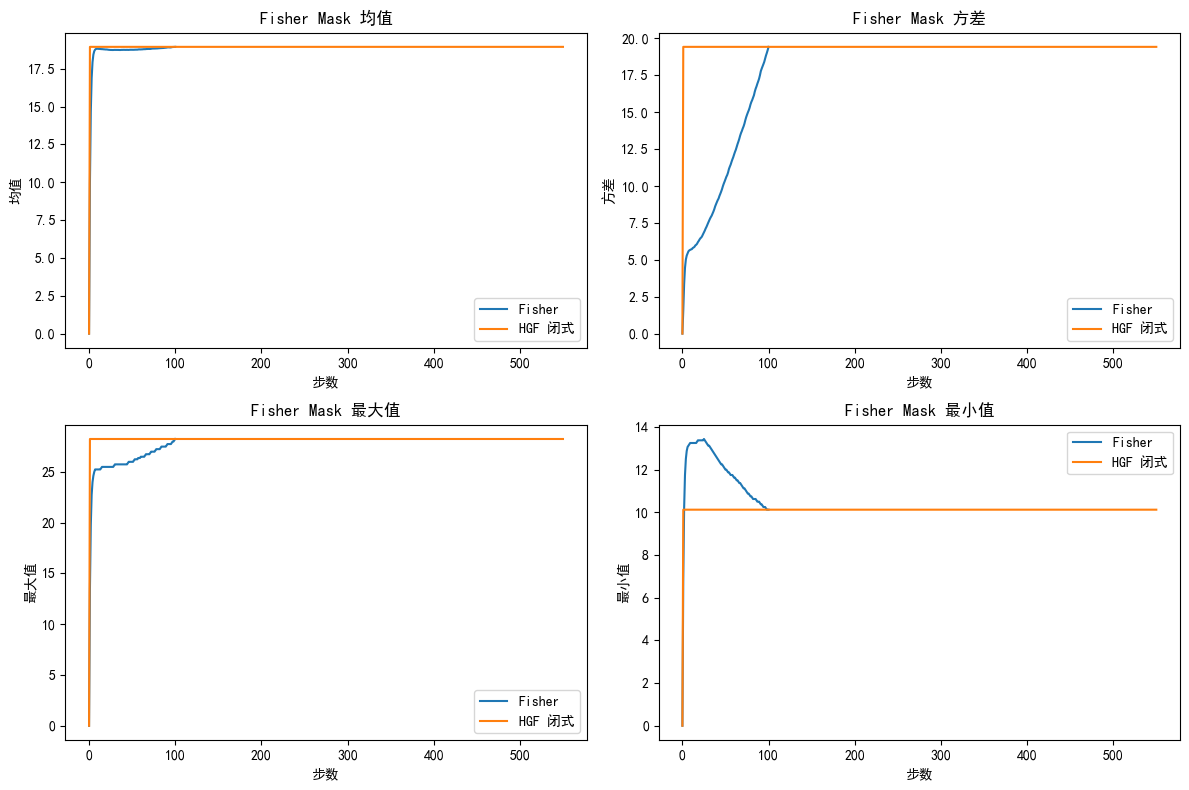

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
in_dim = 128
out_dim = 64
cfg_hf = AeloruConfig(
    in_features=in_dim, 
    out_features=out_dim,
    r=8, 
    lora_alpha=4.0,
    fisher_gamma=0.5,
    use_hebbian=True,
    use_fisher=True,
    fisher_mode='full',
    use_hongwen=False,
    hebbian_lr=1e-2,
    hebbian_accum_steps=1,
    hebbian_before_backprop=True,
    use_hgf_fisher=True,
    use_homeostatic_plasticity=True,
)

batch_size = 16
layer_hf = AeloruLayer(in_dim, out_dim, cfg_hf).to(device)
layer_hf.set_pretrained_weight(torch.randn(out_dim, in_dim, device=device) * 0.02)
layer_hf.train()

def print_fisher_stats(tag: str):
    f = layer_hf.fisher_mask.float()
    print(f"  [{tag}] Fisher 统计:")
    print(f"    均值: {f.mean().item():.6f}")
    print(f"    方差: {f.var().item():.8f}")
    print(f"    最大值: {f.max().item():.6f}")
    print(f"    最小值: {f.min().item():.6f}")

print_fisher_stats("冲击前")

fixed_x = torch.randn(batch_size, in_dim, device=device, dtype=AeloruConfig.AMP_DTYPE)
hf_log_ms = [0]
hf_log_s_2 = [0]
hf_log_max =[0]
hf_log_min = [0]
# 第一次冲击
for _ in range(50):
    y = layer_hf(fixed_x)
    layer_hf.post_step_update(fixed_x, y, is_correct=True)
    f = layer_hf.fisher_mask.float()
    hf_log_ms.append(f.mean().item())
    hf_log_s_2.append(f.var().item())
    hf_log_max.append(f.max().item())
    hf_log_min.append(f.min().item())
print_fisher_stats("第一次冲击后 (50步)")

# 第二次冲击
for _ in range(50):
    y = layer_hf(fixed_x)
    layer_hf.post_step_update(fixed_x, y, is_correct=True)
    f = layer_hf.fisher_mask.float()
    hf_log_ms.append(f.mean().item())
    hf_log_s_2.append(f.var().item())
    hf_log_max.append(f.max().item())
    hf_log_min.append(f.min().item())

print_fisher_stats("第二次持续冲击后 (100步)")

#测试3 补充使用HGF 闭式更新验证 Hebbian-Fisher 双向联动
print("\n测试 3.1: HGF 闭式更新验证")
cfg_hf_hgf = AeloruConfig(
    in_features=in_dim, 
    out_features=out_dim,
    r=8, 
    lora_alpha=4.0,
    fisher_gamma=0.5,
    use_hebbian=True,
    use_fisher=False,  # 关闭常规 Fisher，验证 HGF 闭式路径
    fisher_mode='off',
    use_hgf_closed_form=True,
    use_hongwen=False,
    hebbian_lr=1e-2,
    hebbian_accum_steps=1,
    hebbian_before_backprop=True,
    use_hgf_fisher=True,
    use_homeostatic_plasticity=True,
)

hgf_log_ms = [0]
hgf_log_s_2 = [0]
hgf_log_max =[0]
hgf_log_min = [0]

layer_hf_hgf = AeloruLayer(in_dim, out_dim, cfg_hf_hgf).to(device)
layer_hf_hgf.set_pretrained_weight(torch.randn(out_dim, in_dim, device=device) * 0.02)
layer_hf_hgf.train()
# 第一次冲击
for _ in range(50):
    y = layer_hf_hgf(fixed_x)
    layer_hf_hgf.post_step_update(fixed_x, y, is_correct=True)
    try:
        f = layer_hf_hgf.fisher_mask.float()
    except:pass
    hgf_log_ms.append(f.mean().item())
    hgf_log_s_2.append(f.var().item())
    hgf_log_max.append(f.max().item())
    hgf_log_min.append(f.min().item())


print_fisher_stats("第一次冲击后 (50步)")

# 第二次冲击
for _ in range(500):
    y = layer_hf_hgf(fixed_x)
    layer_hf_hgf.post_step_update(fixed_x, y, is_correct=True)
    try:
        f = layer_hf_hgf.fisher_mask.float()
    except:pass
    hgf_log_ms.append(f.mean().item())
    hgf_log_s_2.append(f.var().item())
    hgf_log_max.append(f.max().item())
    hgf_log_min.append(f.min().item())

print_fisher_stats("第二次持续冲击后 (100步)")

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(hf_log_ms, label='Fisher')
plt.plot(hgf_log_ms, label='HGF 闭式')
plt.title('Fisher Mask 均值')
plt.xlabel('步数')
plt.ylabel('均值')
plt.legend()
plt.subplot(2, 2, 2)
plt.plot(hf_log_s_2, label='Fisher')
plt.plot(hgf_log_s_2, label='HGF 闭式')
plt.title('Fisher Mask 方差')
plt.xlabel('步数')
plt.ylabel('方差')
plt.legend()
plt.subplot(2, 2, 3)
plt.plot(hf_log_max, label='Fisher')
plt.plot(hgf_log_max, label='HGF 闭式')
plt.title('Fisher Mask 最大值')
plt.xlabel('步数')
plt.ylabel('最大值')
plt.legend()
plt.subplot(2, 2, 4)
plt.plot(hf_log_min, label='Fisher')
plt.plot(hgf_log_min, label='HGF 闭式')
plt.title('Fisher Mask 最小值')
plt.xlabel('步数')
plt.ylabel('最小值')
plt.legend()
plt.tight_layout()

## 单任务性能对比实验（证明 "不牺牲单任务换连续学习"）
> 实验目的：证明 Aeloru 在单任务微调上，性能和主流 PEFT 方法相当，没有为了连续学习牺牲基础能力
### 实验设计：
1. 分别用 LoRA、DoRA、ReLoRA、Aeloru 在上述 5 个数据集上做单任务微调
2. 记录每个方法在每个数据集上的最终准确率和困惑度
3. 用表格呈现结果，最后一行加平均性能

In [ ]:
from sympy import use


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = "../../models/Qwen2.5-0.5B"
MAX_SEQ_LENGTH = 128
BATCH_SIZE = 16
NUM_EPOCHS = 3
LR = 2e-4
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
SEED = 42

AMP_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
USE_AMP = True

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATASET_CONFIGS = [
    {"name": "glue", "config": "sst2", "text_cols": ["sentence"], "label_col": "label", "num_labels": 2},
    {"name": "glue", "config": "mrpc", "text_cols": ["sentence1", "sentence2"], "label_col": "label", "num_labels": 2},
    {"name": "glue", "config": "qnli", "text_cols": ["question", "sentence"], "label_col": "label", "num_labels": 2},
    {"name": "glue", "config": "rte",  "text_cols": ["sentence1", "sentence2"], "label_col": "label", "num_labels": 2},
    {"name": "glue", "config": "cola", "text_cols": ["sentence"], "label_col": "label", "num_labels": 2},
]

LORA_R = 8
LORA_ALPHA = 4.0
LORA_DROPOUT = 0.1
TARGET_MODULES = ["q_proj", "v_proj"]


# ========================= ReLoRA =========================

class ReLoRATrainer:
    def __init__(self, model, merge_every: int = 1000, lr: float = LR):
        self.model = model
        self.merge_every = merge_every
        self.lr = lr

    def maybe_merge_and_reinit(self, global_step: int):
        if global_step > 0 and global_step % self.merge_every == 0:
            print(f"[ReLoRA] Merging at step {global_step}...")
            self._merge_lora_weights()
            self._reset_lora_parameters()

    def _merge_lora_weights(self):
        for module in self.model.named_modules():
            if hasattr(module, 'lora_A') and hasattr(module, 'lora_B'):
                scaling = getattr(module, 'scaling', module.lora_alpha / module.r)
                delta = (module.lora_B @ module.lora_A) * scaling
                module.base_layer.weight.data.add_(delta.t())

    def _reset_lora_parameters(self):
        for module in self.model.named_modules():
            if hasattr(module, 'lora_A') and hasattr(module, 'lora_B'):
                nn.init.kaiming_uniform_(module.lora_A, a=math.sqrt(5))
                nn.init.zeros_(module.lora_B)


# ========================= 数据集 =========================

def load_and_preprocess_dataset(ds_cfg: Dict, tokenizer):
    raw = load_dataset(ds_cfg["name"], ds_cfg["config"])
    text_cols = ds_cfg["text_cols"]
    label_col = ds_cfg["label_col"]

    def tokenize_fn(examples):
        if len(text_cols) == 1:
            return tokenizer(examples[text_cols[0]], truncation=True, max_length=MAX_SEQ_LENGTH, padding=False)
        else:
            return tokenizer(examples[text_cols[0]], examples[text_cols[1]],
                           truncation=True, max_length=MAX_SEQ_LENGTH, padding=False)

    encoded = raw.map(tokenize_fn, batched=True)
    cols_to_remove = list(text_cols)
    for split in encoded.keys():
        for col in list(encoded[split].column_names):
            if col not in ["input_ids", "attention_mask", label_col]:
                cols_to_remove.append(col)
    cols_to_remove = list(set(cols_to_remove))
    encoded = encoded.remove_columns(cols_to_remove)
    if label_col != "labels":
        encoded = encoded.rename_column(label_col, "labels")
    encoded.set_format("torch")
    return encoded


# ========================= 评估 =========================

def compute_metrics(eval_preds, eval_loss: float) -> Dict[str, float]:
    logits, labels = eval_preds
    preds = np.argmax(logits, axis=-1)
    acc = (preds == labels).mean()
    ppl = math.exp(eval_loss) if eval_loss < 10 else float('inf')
    return {"accuracy": acc, "perplexity": ppl}


def create_peft_model(method: str, num_labels: int, pad_token_id: int):
    base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels, trust_remote_code=True,
    ).to(DEVICE)
    base.config.pad_token_id = pad_token_id

    if method == "LoRA":
        config = LoraConfig(
            r=LORA_R, lora_alpha=int(LORA_ALPHA), target_modules=TARGET_MODULES,
            lora_dropout=LORA_DROPOUT, bias="none", task_type=TaskType.SEQ_CLS,
        )
        model = get_peft_model(base, config)

    elif method == "DoRA":
        try:
            config = LoraConfig(
                r=LORA_R, lora_alpha=int(LORA_ALPHA), target_modules=TARGET_MODULES,
                lora_dropout=LORA_DROPOUT, bias="none", task_type=TaskType.SEQ_CLS,
                use_dora=True,
            )
            model = get_peft_model(base, config)
        except Exception as e:
            print(f"[Warn] DoRA fallback: {e}")
            config = LoraConfig(
                r=LORA_R, lora_alpha=int(LORA_ALPHA), target_modules=TARGET_MODULES,
                lora_dropout=LORA_DROPOUT, bias="none", task_type=TaskType.SEQ_CLS,
            )
            model = get_peft_model(base, config)
            for module in model.named_modules():
                if hasattr(module, 'lora_A') and hasattr(module, 'base_layer'):
                    module.magnitude = nn.Parameter(module.base_layer.weight.norm(p=2, dim=1).detach().clone())

    elif method == "ReLoRA":
        config = LoraConfig(
            r=LORA_R, lora_alpha=int(LORA_ALPHA), target_modules=TARGET_MODULES,
            lora_dropout=LORA_DROPOUT, bias="none", task_type=TaskType.SEQ_CLS,
        )
        model = get_peft_model(base, config)

    elif method == "Aeloru":
        cfg = AeloruConfig(r=LORA_R, lora_alpha=LORA_ALPHA, LoRA_lr=LR,
                           use_fisher=False,use_hgf_closed_form=True,use_predictive_coding=True,use_source_domain_constraint=True,use_online_covariance=True,use_whitening=True,verbose=False,hebbian_before_backprop=True)
        model = inject_aeloru(base, target_names=TARGET_MODULES, cfg=cfg)

    else:
        raise ValueError(f"Unknown method: {method}")

    return model


# ========================= 训练 =========================

def train_and_evaluate(method: str, dataset_cfg: Dict, tokenizer, pad_token_id: int):
    print(f"\n{'='*60}")
    print(f"Method: {method:8s} | Dataset: {dataset_cfg['config'].upper()}")
    print(f"{'='*60}")

    encoded = load_and_preprocess_dataset(dataset_cfg, tokenizer)
    collator = DataCollatorWithPadding(tokenizer)
    train_loader = DataLoader(encoded["train"], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator)
    val_key = "validation_matched" if dataset_cfg["config"] == "mnli" else "validation"
    eval_loader = DataLoader(encoded[val_key], batch_size=BATCH_SIZE, collate_fn=collator)

    model = create_peft_model(method, dataset_cfg["num_labels"], pad_token_id)
    model.to(DEVICE)

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)
    total_steps = len(train_loader) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(total_steps * WARMUP_RATIO), num_training_steps=total_steps
    )

    relora_trainer = ReLoRATrainer(model, merge_every=1000, lr=LR) if method == "ReLoRA" else None

    aeloru_layers = [m for m in model.modules() if isinstance(m, AeloruLayer)] if method == "Aeloru" else []

    epoch_train_losses = []
    epoch_eval_losses = []
    global_step = 0
    best_eval_acc = 0.0
    final_metrics = {}

    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

        for batch in pbar:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad()

            # bf16 前向(无需 GradScaler）
            with autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                outputs = model(**batch)
                loss = outputs.loss
                if method == "Aeloru" and aeloru_layers:
                    ortho_loss = sum(layer.ortho_penalty() for layer in aeloru_layers if hasattr(layer, 'ortho_penalty'))
                    loss = loss + ortho_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step()
            scheduler.step()

            if method == "Aeloru" and aeloru_layers:
                for layer in aeloru_layers:
                    if hasattr(layer, 'fisher_update') and layer.lora_A.grad is not None:
                        grad_delta = (layer.lora_A.grad @ layer.lora_B.detach().t() +
                                      layer.lora_A.detach() @ layer.lora_B.grad.t()) * layer.scaling
                        layer.fisher_update(grad_delta)

            if relora_trainer:
                relora_trainer.maybe_merge_and_reinit(global_step)

            global_step += 1
            epoch_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_train_loss = epoch_loss / len(train_loader)
        epoch_train_losses.append(avg_train_loss)

        # 评估
        model.eval()
        all_logits, all_labels = [], []
        eval_loss_sum = 0.0
        with torch.no_grad():
            for batch in eval_loader:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                outputs = model(**batch)
                eval_loss_sum += outputs.loss.item() * batch["input_ids"].size(0)
                all_logits.append(outputs.logits.float().cpu().numpy())  # bf16→fp32
                all_labels.append(batch["labels"].cpu().numpy())

        eval_loss = eval_loss_sum / len(eval_loader.dataset)
        epoch_eval_losses.append(eval_loss)

        metrics = compute_metrics((np.concatenate(all_logits), np.concatenate(all_labels)), eval_loss)
        print(f"  Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | "
              f"Eval Loss: {eval_loss:.4f} | Acc: {metrics['accuracy']:.4f} | PPL: {metrics['perplexity']:.2f}")

        if metrics["accuracy"] > best_eval_acc:
            best_eval_acc = metrics["accuracy"]
            final_metrics = metrics.copy()

    del model, optimizer
    torch.cuda.empty_cache()
    return final_metrics, epoch_train_losses, epoch_eval_losses


# ========================= 绘图 =========================

def plot_all_loss_curves(all_results: Dict):
    methods = ["LoRA", "DoRA", "ReLoRA", "Aeloru"]
    datasets = [cfg["config"].upper() for cfg in DATASET_CONFIGS]
    fig, axes = plt.subplots(len(datasets), 1, figsize=(12, 4 * len(datasets)))
    if len(datasets) == 1:
        axes = [axes]
    colors = {"LoRA": "#1f77b4", "DoRA": "#ff7f0e", "ReLoRA": "#2ca02c", "Aeloru": "#d62728"}

    for idx, ds_name in enumerate(datasets):
        ax = axes[idx]
        for method in methods:
            if ds_name in all_results.get(method, {}):
                _, train_losses, eval_losses = all_results[method][ds_name]
                epochs = list(range(1, len(train_losses) + 1))
                ax.plot(epochs, train_losses, color=colors[method], linestyle='-', marker='o', label=f"{method} Train", alpha=0.8)
                ax.plot(epochs, eval_losses, color=colors[method], linestyle='--', marker='s', label=f"{method} Eval", alpha=0.8)
        ax.set_title(f"Loss Curves - {ds_name}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Epoch", fontsize=12)
        ax.set_ylabel("Loss", fontsize=12)
        ax.legend(loc='upper right', fontsize=8, ncol=2)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(epochs)

    plt.tight_layout()
    plt.savefig("loss_curves_all_datasets.png", dpi=150, bbox_inches='tight')
    print("\nLoss 曲线图已保存至 loss_curves_all_datasets.png")
    plt.show()


# ========================= 主入口 =========================

def run_experiment():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    pad_token_id = tokenizer.pad_token_id
    print(f"[Tokenizer] pad_token: {tokenizer.pad_token}, pad_token_id: {pad_token_id}")
    print(f"[AMP] dtype={AMP_DTYPE}, enabled={USE_AMP}")

    # methods = ["LoRA", "DoRA", "ReLoRA", "Aeloru"]
    methods = ["Aeloru"]
    results = defaultdict(dict)
    all_loss_records = defaultdict(dict)

    for ds_cfg in DATASET_CONFIGS:
        ds_name = ds_cfg["config"].upper()
        for method in methods:
            try:
                metrics, train_losses, eval_losses = train_and_evaluate(method, ds_cfg, tokenizer, pad_token_id)
                results[method][ds_name] = metrics
                all_loss_records[method][ds_name] = (metrics, train_losses, eval_losses)
            except Exception as e:
                print(f"[ERROR] {method} on {ds_name}: {e}")
                import traceback
                traceback.print_exc()
                results[method][ds_name] = {"accuracy": 0.0, "perplexity": float('inf')}
                all_loss_records[method][ds_name] = (
                    {"accuracy": 0.0, "perplexity": float('inf')},
                    [float('inf')] * NUM_EPOCHS, [float('inf')] * NUM_EPOCHS,
                )

    rows = []
    for method in methods:
        row = {"Method": method}
        accs, ppls = [], []
        for ds_cfg in DATASET_CONFIGS:
            ds_name = ds_cfg["config"].upper()
            m = results[method].get(ds_name, {"accuracy": 0.0, "perplexity": float('inf')})
            row[f"{ds_name}_Acc"] = f"{m['accuracy']:.4f}"
            row[f"{ds_name}_PPL"] = f"{m['perplexity']:.2f}"
            accs.append(m["accuracy"])
            ppls.append(m["perplexity"] if m["perplexity"] != float('inf') else 100)
        row["Avg_Acc"] = f"{np.mean(accs):.4f}"
        row["Avg_PPL"] = f"{np.mean(ppls):.2f}"
        rows.append(row)

    df = pd.DataFrame(rows)
    print("\n" + "="*80)
    print("实验结果汇总表")
    print("="*80)
    print(df.to_string(index=False))
    df.to_csv("peft_comparison_results.csv", index=False, encoding="utf-8-sig")
    print("\n结果已保存至 peft_comparison_results.csv")
    plot_all_loss_curves(all_loss_records)
    return df


if __name__ == "__main__":
    df = run_experiment()

[Tokenizer] pad_token: <|endoftext|>, pad_token_id: 151643
[AMP] dtype=torch.bfloat16, enabled=True

Method: Aeloru   | Dataset: SST2


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 4833.40it/s]
Qwen2ForSequenceClassification LOAD REPORT from: ../../models/Qwen2.5-0.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1/3:   0%|          | 0/4210 [00:00<?, ?it/s]

Input x shape: torch.Size([16, 30, 896])
None
[ERROR] Aeloru on SST2: The size of tensor a (30) must match the size of tensor b (480) at non-singleton dimension 1

Method: Aeloru   | Dataset: MRPC



Traceback (most recent call last):
  File "C:\Users\ZhuanZ1\AppData\Local\Temp\ipykernel_10876\1497462975.py", line 302, in run_experiment
    metrics, train_losses, eval_losses = train_and_evaluate(method, ds_cfg, tokenizer, pad_token_id)
                                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ZhuanZ1\AppData\Local\Temp\ipykernel_10876\1497462975.py", line 195, in train_and_evaluate
    outputs = model(**batch)
              ^^^^^^^^^^^^^^
  File "e:\Conda\envs\Qelys\Lib\site-packages\torch\nn\modules\module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Conda\envs\Qelys\Lib\site-packages\torch\nn\modules\module.py", line 1845, in _call_impl
    return inner()
           ^^^^^^^
  File "e:\Conda\envs\Qelys\Lib\site-packages\torch\nn\modules\module.py", line 1793, in inner
    result = forward_call(*args, **kwargs)
             ^^^^^^^

KeyboardInterrupt: 